## Final Project - ML Techniquew
Employing Linear Regression as a baseline model to predict which video games will be more successful/popular based on various aspects

By: Miyuki Randle and Marco Hidalgo Romero

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv("steam.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

#### **Data Cleaning**

In [2]:
# Check/Handle Missing Values
df.isnull().sum()

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

In [3]:
# Based on the results above, there are missing values in certain rows for the publisher and developer
# Since only very small number of rows are missing categorical values, I chose to fill them with 'Unknown' to preserve the dataset size while maintaining data consistency
df["publisher"].fillna("Unknown", inplace=True)
df["developer"].fillna("Unknown", inplace=True)

C:\Users\marco\AppData\Local\Temp\ipykernel_28528\752127825.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["publisher"].fillna("Unknown", inplace=True)
C:\Users\marco\AppData\Local\Temp\ipykernel_28528\752127825.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

#### **Class Imbalance**

For a Linear Regression, class imbalance is not a concern since this is not a classification problem, there is no issue with having a biased majority class.

However there is a different balancing issue that does need to be addressed with Linear Regression which is possible skewed distribution, expecially for the particular dataset, so this will be addressed later.

#### **Feature Engineering**

In [4]:
# Defining the target
#Ratings tell you: Do people like it?
#Playtime tell you: Do people stay?
#Owners tell you: Did it succeed?

# Owners midpoint
df["owners_mid"] = df["owners"].apply(lambda x: (int(x.split('-')[0]) + int(x.split('-')[1])) / 2)

# Rating ratio
df["rating_ratio"] = df["positive_ratings"] / (df["positive_ratings"] + df["negative_ratings"])
df["rating_ratio"] = df["rating_ratio"].fillna(0)

# The Linear Regression could get dominated by the few major games but perform poorly on more average games
# To avoid this I am using Log Transformations
df["owners_log"] = np.log1p(df["owners_mid"])
df["playtime_log"] = np.log1p(df["average_playtime"])

from sklearn.preprocessing import MinMaxScaler

# Normalize components for success score
scaler = MinMaxScaler()
df["owners_scaled"] = scaler.fit_transform(df[["owners_log"]])
df["playtime_scaled"] = scaler.fit_transform(df[["playtime_log"]])

# Create combined success score
# Weights are assigned to prioritize popularity, but still accounting for player satisfaction, and engagement
df["success_score"] = (
    0.5 * df["owners_scaled"] +
    0.3 * df["rating_ratio"] +
    0.2 * df["playtime_scaled"]
)

df["price_log"] = np.log1p(df["price"])
df["is_free"] = (df["price"] == 0).astype(int)
df["year"] = pd.to_datetime(df["release_date"]).dt.year
df["years_since_release"] = 2024 - df["year"]

#### **Feature Selection**

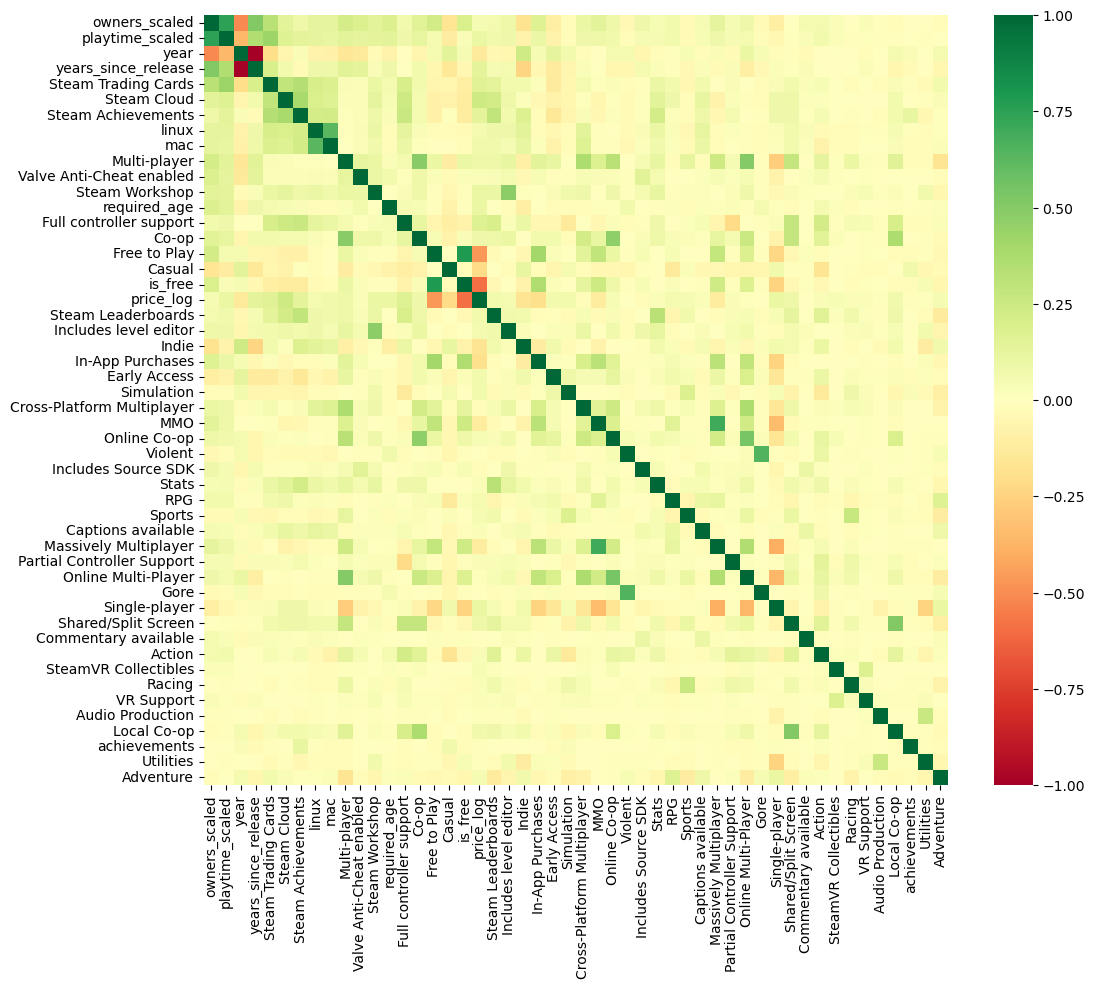

In [5]:
# Prepare X and y
y = df["success_score"] # Target

# Drop columns used for combined success target and other non-numeric irrelevant columnss
X = df.drop(columns=[
    "success_score",
    "name",
    "appid",
    "release_date",
    "price",
    "developer",
    "publisher",
    "english",
    "owners",
    "owners_mid",
    "owners_log",
    "average_playtime",
    "median_playtime",
    "playtime_log",
    "positive_ratings",
    "negative_ratings",
    "rating_ratio",
])

# Potential Categorical features need to be need to be encoded
X = X.join(df["genres"].str.get_dummies(sep=";"))
X = X.join(df["categories"].str.get_dummies(sep=";"))
X = X.join(df["platforms"].str.get_dummies(sep=";"))
X = X.drop(columns=["genres", "categories", "platforms", "steamspy_tags"], errors="ignore")

X = X.select_dtypes(include=["number"])

# Variance Threshold
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.001)
selector.fit(X)

X_selected = X.loc[:, selector.get_support()]

# Correlation Filtering
corr_matrix = X_selected.corrwith(y).abs().sort_values(ascending=False)
top_features = corr_matrix.head(50).index
X_selected = X_selected[top_features]

# Plot Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(X_selected.corr(), cmap="RdYlGn")
plt.show()

In [6]:
X_selected

,owners_scaled,playtime_scaled,year,years_since_release,Steam Trading Cards,Steam Cloud,Steam Achievements,linux,mac,Multi-player,...,Commentary available,Action,SteamVR Collectibles,Racing,VR Support,Audio Production,Local Co-op,achievements,Utilities,Adventure
0,0.760539,0.804107,2000,24,0,0,0,1,1,1,...,0,1,0,0,0,0,0,0,0,0
1,0.688454,0.462871,1999,25,0,0,0,1,1,1,...,0,1,0,0,0,0,0,0,0,0
2,0.688454,0.430697,2003,21,0,0,0,1,1,1,...,0,1,0,0,0,0,0,0,0,0
3,0.688454,0.457049,2001,23,0,0,0,1,1,1,...,0,1,0,0,0,0,0,0,0,0
4,0.688454,0.529504,1999,25,0,0,0,1,1,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27070,0.000000,0.000000,2019,5,0,0,1,0,0,0,...,0,0,0,0,0,0,0,7,0,1
27071,0.000000,0.000000,2019,5,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
27072,0.000000,0.000000,2019,5,0,1,1,0,0,1,...,0,1,0,0,0,0,0,24,0,0
27073,0.000000,0.000000,2019,5,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
# Adding Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_selected)

**Data Transformation**

In [8]:
# Normalization
from sklearn.preprocessing import StandardScaler

# Scale features for model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

#### **Linear Regression Model Building**

In [9]:
# Split data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=0, test_size=0.2)

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Tuning Ridge Alpha
params = {"alpha": [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(Ridge(), params, cv=5, scoring="r2")
grid.fit(X_train, y_train)

model = grid.best_estimator_

#### **Linear Regression Baseline**

In [10]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_pred = np.full_like(y_test, y_train.mean())
print(mean_squared_error(y_test, baseline_pred))

0.01614477458684855


#### **Linear Regression Cross Validation**

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring="r2")
print(scores.mean())

0.5678771430581354


#### **Linear Regression Evaluation**

In [12]:
from sklearn import metrics

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print("Train MAE:", metrics.mean_absolute_error(y_train, pred_train))
print("Test MAE:", metrics.mean_absolute_error(y_test, pred_test))

print("Train RMSE:", np.sqrt(metrics.mean_squared_error(y_train, pred_train)))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, pred_test)))

print("Train R2:", metrics.r2_score(y_train, pred_train))
print("Test R2:", metrics.r2_score(y_test, pred_test))

Train MAE: 0.04817536872739932
Test MAE: 0.051363406154465545
Train RMSE: 0.06297835131679345
Test RMSE: 0.06711321050550698
Train R2: 0.7556811537428139
Test R2: 0.7208713663420004


#### **Linear Regression Reisidual Plot**

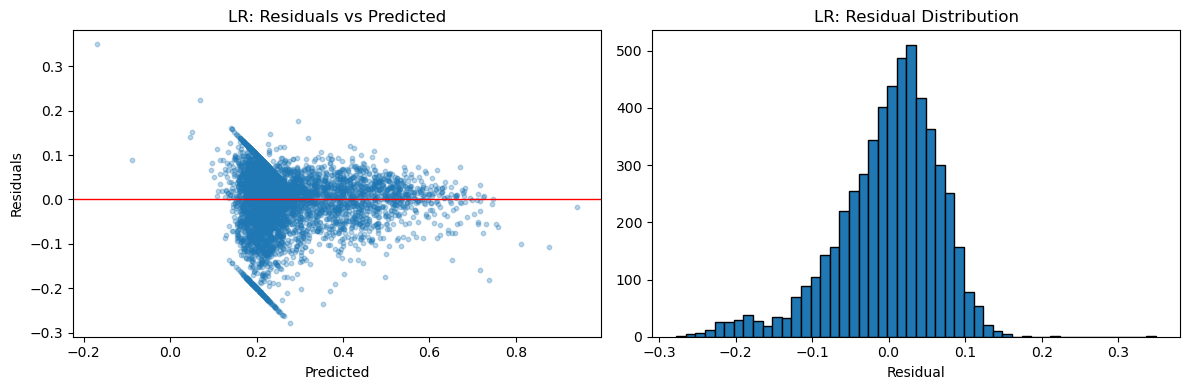

In [13]:
# Residual Analysis
residuals_lr = y_test.values - pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_test, residuals_lr, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")
axes[0].set_title("LR: Residuals vs Predicted")

axes[1].hist(residuals_lr, bins=50, edgecolor="black")
axes[1].set_xlabel("Residual")
axes[1].set_title("LR: Residual Distribution")

plt.tight_layout()
plt.show()

#### **Random Forest Model Building**

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,          # "None" default value results in unlimited depth
    min_samples_leaf=10,   # Default value of 1 results in the same issues as the "None" default value for max_depth
    max_features=0.5,      # We would like to discard features that are irrelevant to our goal
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
print("Random Forest trained.")

Random Forest trained.


#### **Random Forest Baseline**

In [15]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_pred = np.full_like(y_test, y_train.mean())
print(mean_squared_error(y_test, baseline_pred))

0.01614477458684855


#### **Random Forest Cross Validation**

In [16]:
rf_cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring="r2")
print(f"RF CV R² scores: {rf_cv_scores.round(4)}")
print(f"RF Mean CV R²:   {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")

RF CV R² scores: [0.8797 0.7897 0.642  0.3836 0.2086]
RF Mean CV R²:   0.5807 (+/- 0.2507)


#### **Random Forest Evaluation**

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_pred_train = rf_model.predict(X_train)
rf_pred_test  = rf_model.predict(X_test)

mask_rf = y_test != 0

rf_r2   = r2_score(y_test, rf_pred_test)
rf_mae  = mean_absolute_error(y_test, rf_pred_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
rf_mape = np.mean(np.abs((y_test[mask_rf] - rf_pred_test[mask_rf]) / y_test[mask_rf])) * 100

print("=== Random Forest — Test Set ===")
print(f"R²:   {rf_r2:.4f}")
print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}  (baseline: {baseline_rmse:.4f})")
print(f"MAPE: {rf_mape:.2f}%")

print("\n=== Train vs Test (overfitting check) ===")
print(f"Train R²:   {r2_score(y_train, rf_pred_train):.4f}  |  Test R²:   {rf_r2:.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, rf_pred_train)):.4f}  |  Test RMSE: {rf_rmse:.4f}")

=== Random Forest — Test Set ===
R²:   0.7320
MAE:  0.0505
RMSE: 0.0658  (baseline: 0.1271)
MAPE: 25.24%

=== Train vs Test (overfitting check) ===
Train R²:   0.7890  |  Test R²:   0.7320
Train RMSE: 0.0585  |  Test RMSE: 0.0658


#### **Random Forest Residual Plot**

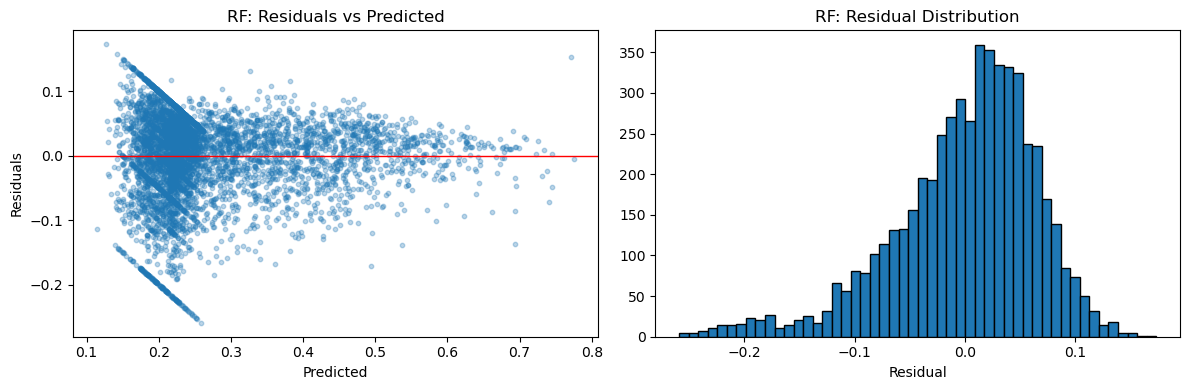

In [21]:
residuals_rf = y_test.values - rf_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(rf_pred_test, residuals_rf, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")
axes[0].set_title("RF: Residuals vs Predicted")

axes[1].hist(residuals_rf, bins=50, edgecolor="black")
axes[1].set_xlabel("Residual")
axes[1].set_title("RF: Residual Distribution")

plt.tight_layout()
plt.show()